<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
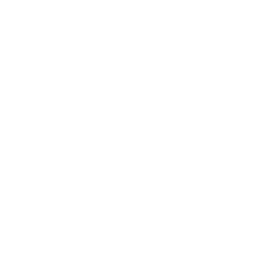
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">四半期から月次への登録内挿</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 製薬／臨床オペレーション &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この実例は、**四半期** 単位の臨床試験登録数を **月次** 推定へと PROC EXPAND で変換し、サイト単位の資源計画を月次のリズムで回せるようにする。この合成試験は、2 地域（北米と欧州）の **4 つの治験実施施設** を **8 四半期**（2024 年第 1 四半期から 2025 年第 4 四半期）にわたってカバーし、**32 の四半期観測** を与える。PROC EXPAND は各サイトの系列を四半期から月次へ内挿し、その 32 の四半期行を **96 の月次行** へと変える。登録数は `METHOD=JOIN`（区分線形で、すべての推定を非負に保つ）で内挿し、累積の走行値は `METHOD=SPLINE` で内挿する。内挿された月次系列は元の四半期アンカー点を厳密に通過するため、この変換は試験が既に報告した四半期の数値を変えることなく、四半期内の詳細を加える。


## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | サイト別の四半期登録数（4 サイト × 8 四半期） | 32 |
| WORK.SITE_MASTER | サイト参照：名称、国、地域、PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
データ work.enrollment_qtr;
    呼出 streaminit(42);
    書式 quarter_date yyq7.;
    配列 capacity[4] _temporary_ (12 9 14 8);
    繰返 site_num = 1 から 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, '北米', '欧州');
        base_rate = capacity[site_num];
        繰返 qtr_seq = 0 から 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            出力;
        終了;
    終了;
    削除 site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
実行;

/* Running cumulative enrollment within each site */
処理 並替 データ=work.enrollment_qtr;
    基準 site_id quarter_date;
実行;

データ work.enrollment_qtr;
    設定 work.enrollment_qtr;
    基準 site_id;
    保存 cum_enrolled 0;
    もし first.site_id なら cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    削除 cum_enrolled;
実行;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
データ work.site_master;
    長さ site_id $8 site_name $60 region $20 country $20 pi_name $30;
    配列 names[4] $60 _temporary_ (
        'メトロ総合病院'   '大学医療センター'
        'ロンドン王立診療所'   'ベルリン・シャリテ・キャンパス'
    );
    配列 countries[4] $20 _temporary_ ('アメリカ' 'アメリカ' 'イギリス' 'ドイツ');
    繰返 i = 1 から 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, '北米', '欧州');
        pi_name   = cat('治験責任医師-', PUT(i, z2.));
        出力;
    終了;
    削除 i;
実行;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
処理 平均 データ=work.enrollment_qtr n sum mean MAX;
    分類 region;
    変数 enrolled_count cumulative_enrolled;
    見出 region='地域' enrolled_count='登録数' cumulative_enrolled='累積登録数';
    出力 out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
実行;

処理 印刷 データ=work.qtr_baseline noobs;
    見出 region='地域' total_enrolled='登録数合計' avg_per_quarter='四半期平均登録数' max_cumulative='最大累積登録数';
    表題 '地域別 四半期登録ベースライン';
実行;


                                                  The MEANS Procedure

                                      Analysis Variable : enrolled_count 登録数

        地域                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        北米                   16    115.0000000      7.1875000     10.0000000
        欧州                   16    120.0000000      7.5000000     13.0000000
        --------------------------------------------------------------------

                                Analysis Variable : cumulative_enrolled 累積登録数

        地域                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        北米                   16    474.0000000     29.6250000     63.0000000
        欧州                   16    493.0000000     30.8125000     81.0000000
        --------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


ベースラインはバランスの取れた設計を裏付ける：各地域は **16 の四半期観測** を寄与する。北米は合計 **115 名**（サイト・四半期あたり平均 **7.19**）、欧州は **120 名**（平均 **7.50**）を登録する。8 四半期で到達した最大累積数は **81 名**（欧州の SITE-003）で、北米の **63** に対する。


---

                                                    地域別 四半期登録ベースライン                                                     




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


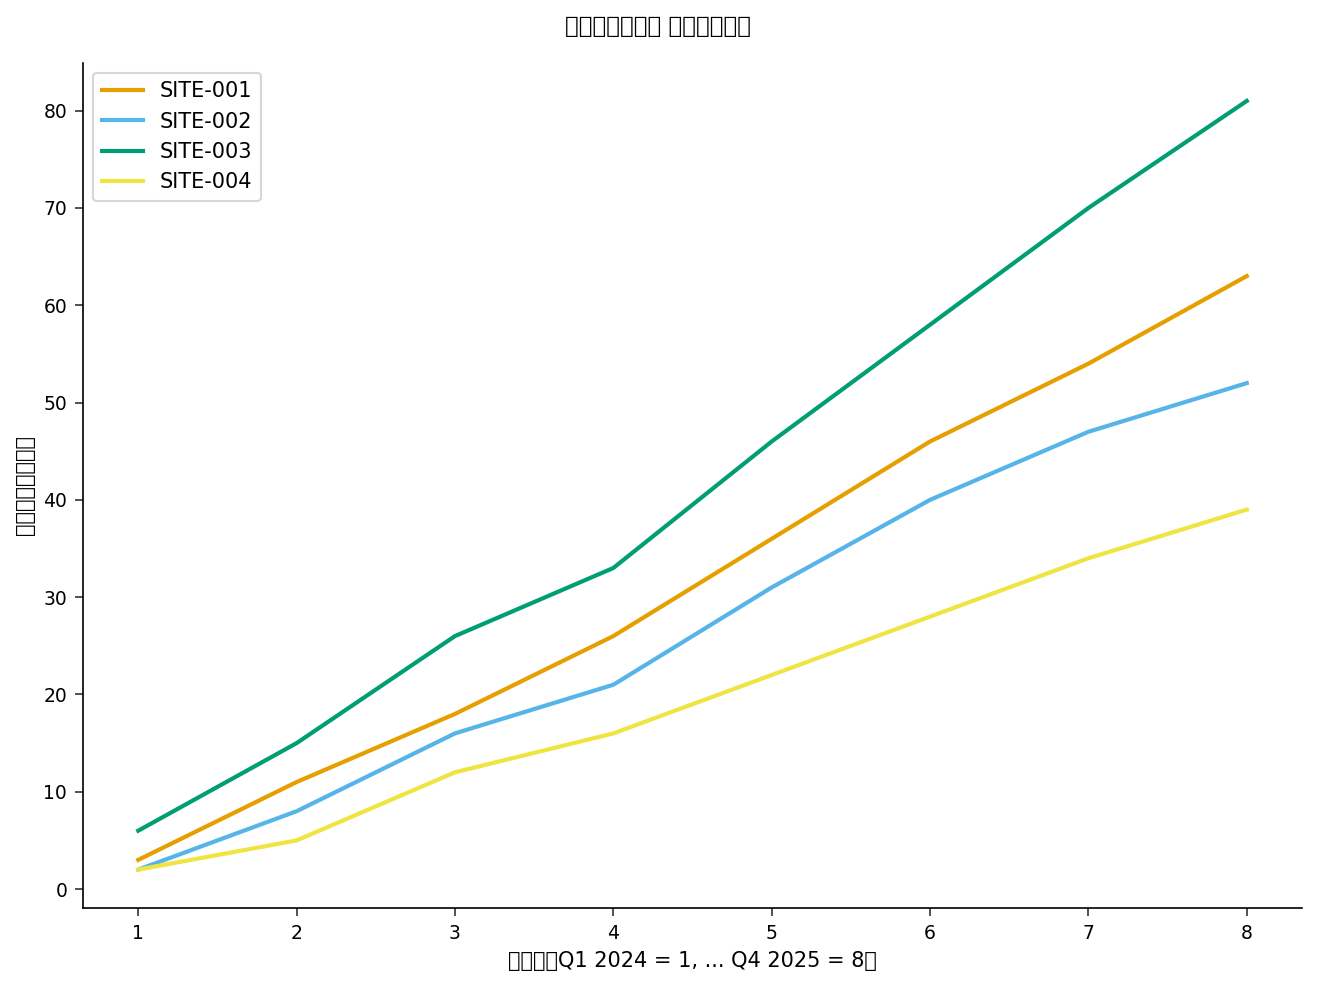

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
データ work.traj;
    設定 work.enrollment_qtr;
    基準 site_id;
    保存 quarter_index 0;
    もし first.site_id なら quarter_index = 0;
    quarter_index + 1;
実行;

処理 SGPLOT データ=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS 見出='四半期（Q1 2024 = 1, ... Q4 2025 = 8）'
        integer VALUES=(1 から 8 基準 1);
    YAXIS 見出='累積登録被験者数';
    表題 '治験実施施設別 累積登録推移';
実行;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
処理 並替 データ=work.enrollment_qtr;
    基準 site_id quarter_date;
実行;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
処理 expand データ=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr から=month;
    基準 site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=終了     METHOD=SPLINE;
実行;


                                                    地域別 四半期登録ベースライン                                                     




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                                    地域別 四半期登録ベースライン                                                     




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


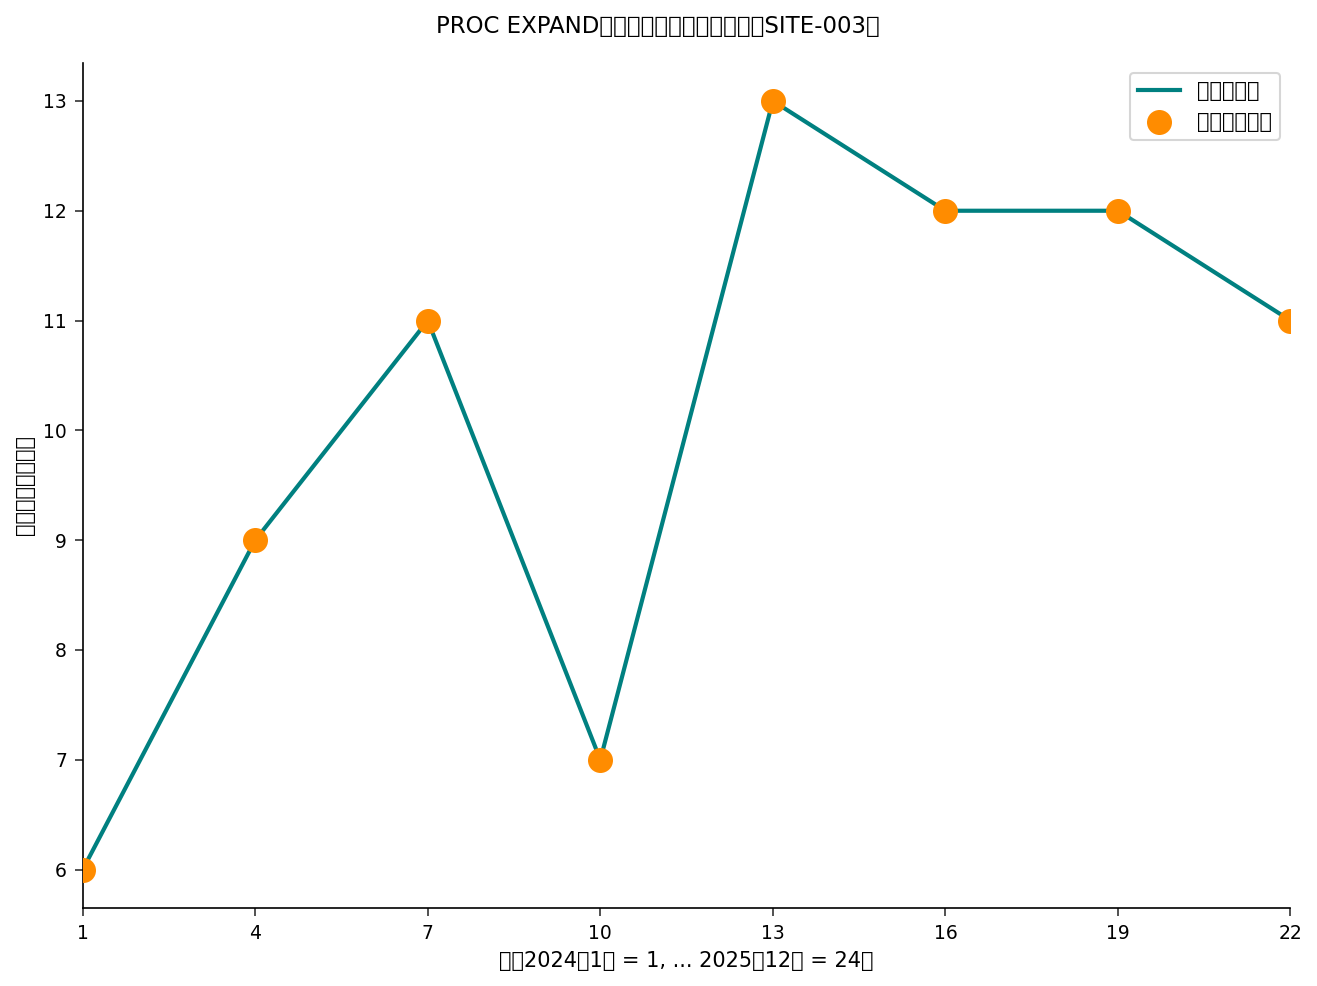

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
データ work.enrollment_monthly;
    設定 work.enrollment_monthly;
    基準 site_id;
    書式 month_date monyy7.;
    month_date = quarter_date;
    保存 month_index 0;
    もし first.site_id なら month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    もし mod(month_index - 1, 3) = 0 なら anchor = enrolled_count;
    他 anchor = .;
実行;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
処理 SGPLOT データ=work.enrollment_monthly;
    条件 site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='月次推定値';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='四半期実測値';
    XAXIS 見出='月（2024年1月 = 1, ... 2025年12月 = 24）'
        integer VALUES=(1 から 24 基準 3);
    YAXIS 見出='月間登録被験者数';
    表題 'PROC EXPAND：四半期登録の月次補間（SITE-003）';
実行;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
処理 SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    選択 e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER 基準 s.region, e.site_id, e.month_date;
QUIT;

処理 平均 データ=work.enrollment_monthly_region n sum mean;
    分類 region;
    変数 monthly_estimate cumulative_estimate;
    見出 region='地域' monthly_estimate='月次推定登録数' cumulative_estimate='累積推定登録数';
    出力 out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
実行;

処理 印刷 データ=work.region_monthly_summary noobs;
    見出 region='地域' total_monthly_enrolled='月次登録数合計' avg_monthly_rate='月次平均登録率';
    表題 '地域別 月次推定値';
実行;


                                                    地域別 四半期登録ベースライン                                                     

                                                    地域別 四半期登録ベースライン                                                     

                                                  The MEANS Procedure

                               Analysis Variable : monthly_estimate 月次推定登録数

        地域                N Obs            Sum           Mean
        -----------------------------------------------------
        北米                   44    326.0000000      7.4090909
        欧州                   44    336.0000000      7.6363636
        -----------------------------------------------------

                             Analysis Variable : cumulative_estimate 累積推定登録数

        地域                N Obs            Sum           Mean
        -----------------------------------------------------
        北米                   48   1312.0000000     27.3333333
        欧州                   48  


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### 解釈

PROC EXPAND は **32 の四半期レコード**（4 サイト × 8 四半期）を、各サイトの日付に沿った頻度変換を用いて **96 の月次レコード** へと変換した。内挿された月次系列は元の四半期アンカー値を厳密に通過する。SITE-003 のプロットが示すとおり、オレンジの点は報告された 8 つの四半期数、ティール色の線はそれらをつなぐ分解された月次推定である。

月次ベースでは 2 地域は近接して推移する。欧州はサイト・月あたり平均 **7.64** 名、北米は **7.41** 名を登録し、内挿した地平における地域の月次合計は **336** 名と **326** 名である。`METHOD=JOIN` は最後の四半期アンカーを越えて外挿しないため、末尾の部分四半期の月々は推定を持たず、月次平均から除外される――これは前方計画にとって保守的な選択である。

これらの月次予測により、臨床オペレーションは四半期から月次の計画リズムへ移行できる――薬剤供給の出荷量の調整、モニタリング訪問のスケジュール、データ安全性モニタリング委員会への登録報告――試験が既に確定した四半期の数値を何ら言い直すことなく行える。


---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
処理 EXPORT データ=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>